# 02 Baseline Strategies: Static Band + TWAP/VWAP

This notebook is the first empirical hedging layer after the simulated executed-trade tape. It follows the updated project plan in `docs/`:

- Convert executed option trades into signed delta arrivals.
- Backtest zero-hedge and full-hedge benchmarks.
- Backtest static no-trade bands around zero delta.
- Execute band-triggered hedge orders using TWAP and VWAP schedules.
- Measure execution cost, residual delta risk, and the combined objective.

Primary input: `data/simulated/simulated_executed_trades.csv`.

Primary output: `outputs/tables/baseline_strategy_results.csv`.

## 1. Setup

In [1]:
from pathlib import Path
import math
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_DIR = PROJECT_ROOT / 'data'
SIM_DIR = DATA_DIR / 'simulated'
PROCESSED_DIR = DATA_DIR / 'processed'
OUTPUT_TABLE_DIR = PROJECT_ROOT / 'outputs' / 'tables'
OUTPUT_FIGURE_DIR = PROJECT_ROOT / 'outputs' / 'figures'

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

EXECUTED_TRADES_PATH = SIM_DIR / 'simulated_executed_trades.csv'
MARKET_INPUTS_PATH = PROCESSED_DIR / 'market_inputs_2026.csv'

OUTPUT_DELTA_ARRIVALS = PROCESSED_DIR / 'executed_trade_delta_arrivals.csv'
OUTPUT_HEDGE_EVENTS = PROCESSED_DIR / 'baseline_hedge_events.csv'
OUTPUT_RESULTS = OUTPUT_TABLE_DIR / 'baseline_strategy_results.csv'

ES_MULTIPLIER = 50
BAR_MINUTES = 5
BAR_YEAR_FRACTION = BAR_MINUTES / (252 * 6.5 * 60)

BAND_GRID = [25_000, 50_000, 100_000, 200_000]
HORIZON_GRID_MINUTES = [15, 30, 60]
EXECUTION_METHODS = ['twap', 'vwap']

SPREAD_BPS = 1.0
IMPACT_ALPHA = 0.05
IMPACT_BETA = 0.5
LAMBDA_RISK = 1e-8

print(PROJECT_ROOT)

C:\Users\chung\Downloads\JPM delta hedging project\JPM_Optimal_Intraday_Delta_Hedging_Strategy


## 2. Load Executed Trades and Market Inputs

In [2]:
def load_executed_trades(path: Path) -> pd.DataFrame:
    trades = pd.read_csv(path)
    trades['timestamp_utc'] = pd.to_datetime(trades['timestamp'], utc=True)
    trades['timestamp_et'] = trades['timestamp_utc'].dt.tz_convert('America/New_York').dt.tz_localize(None)
    trades['trade_date'] = trades['timestamp_et'].dt.normalize()
    trades['expiry_date'] = pd.to_datetime(trades['expiry_date'])
    trades['side'] = trades['side'].str.upper()
    trades['opt_type'] = trades['opt_type'].str.upper()
    return trades.sort_values('timestamp_et').reset_index(drop=True)


def load_market_inputs(path: Path) -> pd.DataFrame:
    market = pd.read_csv(path)
    market['timestamp_et'] = pd.to_datetime(market['timestamp_et'])
    market['trade_date'] = pd.to_datetime(market['trade_date'])
    return market.sort_values('timestamp_et').reset_index(drop=True)


trades_raw = load_executed_trades(EXECUTED_TRADES_PATH)
market = load_market_inputs(MARKET_INPUTS_PATH)

print(f'Executed trades: {len(trades_raw):,}')
print(f'Market bars:     {len(market):,}')
trades_raw.head()

Executed trades: 32,127
Market bars:     8,364


,trade_id,timestamp,sec_of_day,symbol,root,expiry_code,expiry_date,opt_type,strike,side,quantity,bid,ask,exec_price,timestamp_utc,timestamp_et,trade_date
0,1,2026-01-02 14:42:39+00:00,52959,ESM6 P6100,ES,ESM6,2026-06-19,P,6100.0,SELL,2,95.75,96.00,95.345960,2026-01-02 14:42:39+00:00,2026-01-02 09:42:39,2026-01-02
1,2,2026-01-02 14:48:58+00:00,53338,ESH6 C7325,ES,ESH6,2026-03-20,C,7325.0,SELL,15,19.75,20.00,20.209821,2026-01-02 14:48:58+00:00,2026-01-02 09:48:58,2026-01-02
2,3,2026-01-02 14:52:13+00:00,53533,ESM6 P6800,ES,ESM6,2026-06-19,P,6800.0,BUY,15,225.75,226.25,220.270833,2026-01-02 14:52:13+00:00,2026-01-02 09:52:13,2026-01-02
3,4,2026-01-02 14:53:41+00:00,53621,ESH6 C7000,ES,ESH6,2026-03-20,C,7000.0,BUY,1,104.50,104.75,112.590909,2026-01-02 14:53:41+00:00,2026-01-02 09:53:41,2026-01-02
4,5,2026-01-02 14:53:57+00:00,53637,ESH6 P4500,ES,ESH6,2026-03-20,P,4500.0,BUY,5,4.45,4.50,4.632456,2026-01-02 14:53:57+00:00,2026-01-02 09:53:57,2026-01-02


## 3. Align Trades to 5-Minute Market Bars

The execution tape is timestamped at trade time. The backtest works on the same 5-minute grid as the market inputs, so each trade is assigned to the latest available market bar.

In [3]:
def align_trades_to_market(trades: pd.DataFrame, market: pd.DataFrame) -> pd.DataFrame:
    aligned = pd.merge_asof(
        trades.sort_values('timestamp_et'),
        market.sort_values('timestamp_et'),
        on='timestamp_et',
        direction='backward',
        tolerance=pd.Timedelta(minutes=10),
        suffixes=('', '_mkt'),
    )
    missing = aligned['es1_price'].isna().sum()
    if missing:
        print(f'Dropping {missing:,} trades that could not be aligned to a market bar.')
        aligned = aligned.dropna(subset=['es1_price']).copy()
    aligned['bar_time'] = aligned['timestamp_et'].dt.floor(f'{BAR_MINUTES}min')
    return aligned.reset_index(drop=True)


trades_aligned = align_trades_to_market(trades_raw, market)
trades_aligned[['trade_id', 'timestamp_et', 'bar_time', 'symbol', 'opt_type', 'strike', 'quantity', 'es1_price', 'bvol_1m']].head()

,trade_id,timestamp_et,bar_time,symbol,opt_type,strike,quantity,es1_price,bvol_1m
0,1,2026-01-02 09:42:39,2026-01-02 09:40:00,ESM6 P6100,P,6100.0,2,6919.75,0.12025
1,2,2026-01-02 09:48:58,2026-01-02 09:45:00,ESH6 C7325,C,7325.0,15,6931.75,0.12025
2,3,2026-01-02 09:52:13,2026-01-02 09:50:00,ESM6 P6800,P,6800.0,15,6932.75,0.12025
3,4,2026-01-02 09:53:41,2026-01-02 09:50:00,ESH6 C7000,C,7000.0,1,6932.75,0.12025
4,5,2026-01-02 09:53:57,2026-01-02 09:50:00,ESH6 P4500,P,4500.0,5,6932.75,0.12025


## 4. Convert Option Executions to Delta Arrivals

The executed-trade tape is ES option flow, so the framework uses a Black-76-style futures-option delta. This cell creates the signed book-delta arrival from each option execution.

In [4]:
def norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + math.erf(x / math.sqrt(2.0)))


def black76_delta(futures_price: float, strike: float, years: float, vol: float, option_type: str, rate: float = 0.0) -> float:
    years = max(float(years), 1 / 365)
    vol = max(float(vol), 0.01)
    futures_price = max(float(futures_price), 0.01)
    strike = max(float(strike), 0.01)
    discount = math.exp(-float(rate) * years)
    d1 = (math.log(futures_price / strike) + 0.5 * vol**2 * years) / (vol * math.sqrt(years))
    if option_type == 'C':
        return discount * norm_cdf(d1)
    return -discount * norm_cdf(-d1)


def add_delta_arrivals(trades: pd.DataFrame) -> pd.DataFrame:
    out = trades.copy()
    out['dte'] = (out['expiry_date'] - out['trade_date']).dt.days.clip(lower=1)
    out['years_to_expiry'] = out['dte'] / 365.0
    out['delta'] = [
        black76_delta(row.es1_price, row.strike, row.years_to_expiry, row.bvol_1m, row.opt_type, row.sofr_1m_rate)
        for row in out.itertuples(index=False)
    ]
    out['side_sign'] = np.where(out['side'].eq('BUY'), 1.0, -1.0)
    out['signed_delta_contracts'] = out['side_sign'] * out['delta'] * out['quantity'] * ES_MULTIPLIER
    out['signed_delta_notional'] = out['signed_delta_contracts'] * out['es1_price']
    return out


delta_arrivals = add_delta_arrivals(trades_aligned)
delta_arrivals.to_csv(OUTPUT_DELTA_ARRIVALS, index=False)

delta_arrivals[['trade_id', 'timestamp_et', 'symbol', 'side', 'quantity', 'delta', 'signed_delta_contracts', 'signed_delta_notional']].head()

,trade_id,timestamp_et,symbol,side,quantity,delta,signed_delta_contracts,signed_delta_notional
0,1,2026-01-02 09:42:39,ESM6 P6100,SELL,2,-5.538310e-02,5.538310e+00,3.832372e+04
1,2,2026-01-02 09:48:58,ESH6 C7325,SELL,15,1.643766e-01,-1.232825e+02,-8.545632e+05
2,3,2026-01-02 09:52:13,ESM6 P6800,BUY,15,-3.840383e-01,-2.880287e+02,-1.996831e+06
3,4,2026-01-02 09:53:41,ESH6 C7000,BUY,1,4.380888e-01,2.190444e+01,1.518580e+05
4,5,2026-01-02 09:53:57,ESH6 P4500,BUY,5,-2.038048e-15,-5.095119e-13,-3.532319e-09


## 5. Build the Backtest Grid

The event grid combines market bars with delta arrivals. The strategy simulator will update book delta at each bar, apply scheduled child hedge orders, then decide whether a new hedge schedule should replace the current one.

In [5]:
def build_delta_bar_grid(delta_arrivals: pd.DataFrame, market: pd.DataFrame) -> pd.DataFrame:
    arrivals = (
        delta_arrivals.groupby('bar_time', as_index=False)
        .agg(
            option_delta_arrival=('signed_delta_contracts', 'sum'),
            option_delta_notional=('signed_delta_notional', 'sum'),
            n_option_trades=('trade_id', 'count'),
        )
    )
    grid = market.rename(columns={'timestamp_et': 'bar_time'}).copy()
    grid = grid.merge(arrivals, on='bar_time', how='left')
    grid[['option_delta_arrival', 'option_delta_notional', 'n_option_trades']] = grid[
        ['option_delta_arrival', 'option_delta_notional', 'n_option_trades']
    ].fillna(0.0)
    grid['trade_date'] = pd.to_datetime(grid['trade_date'])
    return grid.sort_values('bar_time').reset_index(drop=True)


bar_grid = build_delta_bar_grid(delta_arrivals, market)
bar_grid[['bar_time', 'trade_date', 'es1_price', 'es1_volume_5m', 'option_delta_arrival', 'n_option_trades']].head()

,bar_time,trade_date,es1_price,es1_volume_5m,option_delta_arrival,n_option_trades
0,2026-01-02 09:30:00,2026-01-02,6918.75,40615.0,0.000000,0.0
1,2026-01-02 09:35:00,2026-01-02,6915.25,24586.0,0.000000,0.0
2,2026-01-02 09:40:00,2026-01-02,6919.75,20690.0,5.538310,1.0
3,2026-01-02 09:45:00,2026-01-02,6931.75,33464.0,-123.282465,1.0
4,2026-01-02 09:50:00,2026-01-02,6932.75,25026.0,-142.357479,4.0


## 6. Execution Cost and Scheduling Helpers

In [6]:
def estimate_child_order_cost(delta_contracts: float, price: float, adv: float) -> tuple[float, float, float]:
    """Return total cost, spread cost, and impact cost for an ES child hedge order."""
    qty = abs(float(delta_contracts))
    price = float(price)
    adv = max(float(adv), 1.0)
    half_spread = price * (SPREAD_BPS / 10_000) / 2
    spread_cost = qty * half_spread
    participation = qty / adv
    impact_cost = IMPACT_ALPHA * price * qty * (participation ** IMPACT_BETA)
    return spread_cost + impact_cost, spread_cost, impact_cost


def make_child_schedule(parent_delta: float, start_idx: int, day_grid: pd.DataFrame, horizon_minutes: int, method: str) -> pd.DataFrame:
    n_child = max(int(horizon_minutes / BAR_MINUTES), 1)
    idx = list(range(start_idx, min(start_idx + n_child, len(day_grid))))
    if not idx:
        return pd.DataFrame(columns=['idx', 'hedge_delta'])

    if method == 'twap':
        weights = np.ones(len(idx), dtype=float) / len(idx)
    elif method == 'vwap':
        volume = day_grid.loc[idx, 'es1_volume_5m'].clip(lower=0).fillna(0).to_numpy(dtype=float)
        weights = volume / volume.sum() if volume.sum() > 0 else np.ones(len(idx), dtype=float) / len(idx)
    else:
        raise ValueError(f'Unknown execution method: {method}')

    return pd.DataFrame({'idx': idx, 'hedge_delta': parent_delta * weights})

## 7. Strategy Simulator Framework

In [7]:
def simulate_static_band_day(day_grid: pd.DataFrame, band: float, method: str, horizon_minutes: int) -> tuple[dict, pd.DataFrame]:
    book_delta = 0.0
    active_schedule = pd.DataFrame(columns=['idx', 'hedge_delta'])
    hedge_events = []
    risk_cost = 0.0
    exec_cost = 0.0
    spread_cost = 0.0
    impact_cost = 0.0
    total_abs_hedge = 0.0
    triggers = 0

    day_grid = day_grid.reset_index(drop=True).copy()

    for i, row in day_grid.iterrows():
        book_delta += float(row.option_delta_arrival)

        scheduled = active_schedule.loc[active_schedule['idx'].eq(i), 'hedge_delta']
        hedge_delta = float(scheduled.sum()) if not scheduled.empty else 0.0
        if hedge_delta != 0.0:
            cost, spread, impact = estimate_child_order_cost(hedge_delta, row.es1_price, row.es1_adv_20d)
            exec_cost += cost
            spread_cost += spread
            impact_cost += impact
            total_abs_hedge += abs(hedge_delta)
            book_delta += hedge_delta
            hedge_events.append({
                'bar_time': row.bar_time,
                'event_type': 'child_order',
                'band': band,
                'method': method,
                'horizon_minutes': horizon_minutes,
                'hedge_delta': hedge_delta,
                'book_delta_after': book_delta,
                'exec_cost': cost,
                'spread_cost': spread,
                'impact_cost': impact,
            })

        risk_cost += (book_delta ** 2) * (float(row.bvol_1m) ** 2) * BAR_YEAR_FRACTION

        if abs(book_delta) > band:
            triggers += 1
            parent_order = -book_delta
            active_schedule = make_child_schedule(parent_order, i + 1, day_grid, horizon_minutes, method)
            hedge_events.append({
                'bar_time': row.bar_time,
                'event_type': 'trigger',
                'band': band,
                'method': method,
                'horizon_minutes': horizon_minutes,
                'hedge_delta': parent_order,
                'book_delta_after': book_delta,
                'exec_cost': 0.0,
                'spread_cost': 0.0,
                'impact_cost': 0.0,
            })

    close_delta = -book_delta
    if close_delta != 0.0:
        row = day_grid.iloc[-1]
        cost, spread, impact = estimate_child_order_cost(close_delta, row.es1_price, row.es1_adv_20d)
        exec_cost += cost
        spread_cost += spread
        impact_cost += impact
        total_abs_hedge += abs(close_delta)
        hedge_events.append({
            'bar_time': row.bar_time,
            'event_type': 'close_flatten',
            'band': band,
            'method': method,
            'horizon_minutes': horizon_minutes,
            'hedge_delta': close_delta,
            'book_delta_after': 0.0,
            'exec_cost': cost,
            'spread_cost': spread,
            'impact_cost': impact,
        })

    result = {
        'trade_date': day_grid['trade_date'].iloc[0],
        'strategy': 'static_band',
        'band': band,
        'method': method,
        'horizon_minutes': horizon_minutes,
        'execution_cost': exec_cost,
        'spread_cost': spread_cost,
        'impact_cost': impact_cost,
        'delta_risk': risk_cost,
        'combined_loss': exec_cost + LAMBDA_RISK * risk_cost,
        'n_triggers': triggers,
        'total_abs_hedge_delta': total_abs_hedge,
        'eod_delta_before_flatten': -close_delta,
    }
    return result, pd.DataFrame(hedge_events)

## 8. Benchmark Frameworks

In [8]:
def simulate_zero_hedge_day(day_grid: pd.DataFrame) -> dict:
    book_delta = 0.0
    risk_cost = 0.0
    day_grid = day_grid.reset_index(drop=True)
    for row in day_grid.itertuples(index=False):
        book_delta += float(row.option_delta_arrival)
        risk_cost += (book_delta ** 2) * (float(row.bvol_1m) ** 2) * BAR_YEAR_FRACTION
    close_row = day_grid.iloc[-1]
    close_delta = -book_delta
    exec_cost, spread_cost, impact_cost = estimate_child_order_cost(close_delta, close_row.es1_price, close_row.es1_adv_20d)
    return {
        'trade_date': day_grid['trade_date'].iloc[0],
        'strategy': 'zero_hedge',
        'band': np.nan,
        'method': 'close_only',
        'horizon_minutes': 0,
        'execution_cost': exec_cost,
        'spread_cost': spread_cost,
        'impact_cost': impact_cost,
        'delta_risk': risk_cost,
        'combined_loss': exec_cost + LAMBDA_RISK * risk_cost,
        'n_triggers': 0,
        'total_abs_hedge_delta': abs(close_delta),
        'eod_delta_before_flatten': -close_delta,
    }


def simulate_full_hedge_day(day_grid: pd.DataFrame) -> dict:
    exec_cost = 0.0
    spread_cost = 0.0
    impact_cost = 0.0
    total_abs_hedge = 0.0
    n_triggers = 0
    day_grid = day_grid.reset_index(drop=True)
    for row in day_grid.itertuples(index=False):
        arrival = float(row.option_delta_arrival)
        if arrival != 0.0:
            hedge_delta = -arrival
            cost, spread, impact = estimate_child_order_cost(hedge_delta, row.es1_price, row.es1_adv_20d)
            exec_cost += cost
            spread_cost += spread
            impact_cost += impact
            total_abs_hedge += abs(hedge_delta)
            n_triggers += 1
    return {
        'trade_date': day_grid['trade_date'].iloc[0],
        'strategy': 'full_hedge',
        'band': 0.0,
        'method': 'immediate',
        'horizon_minutes': 0,
        'execution_cost': exec_cost,
        'spread_cost': spread_cost,
        'impact_cost': impact_cost,
        'delta_risk': 0.0,
        'combined_loss': exec_cost,
        'n_triggers': n_triggers,
        'total_abs_hedge_delta': total_abs_hedge,
        'eod_delta_before_flatten': 0.0,
    }

## 9. Run the Baseline Grid

In [9]:
results = []
hedge_logs = []

for trade_date, day_grid in bar_grid.groupby('trade_date'):
    day_grid = day_grid.sort_values('bar_time').reset_index(drop=True)
    results.append(simulate_zero_hedge_day(day_grid))
    results.append(simulate_full_hedge_day(day_grid))

    for band in BAND_GRID:
        for method in EXECUTION_METHODS:
            for horizon in HORIZON_GRID_MINUTES:
                day_result, day_hedges = simulate_static_band_day(day_grid, band, method, horizon)
                results.append(day_result)
                if not day_hedges.empty:
                    day_hedges['trade_date'] = trade_date
                    hedge_logs.append(day_hedges)

results_df = pd.DataFrame(results)
hedge_events = pd.concat(hedge_logs, ignore_index=True) if hedge_logs else pd.DataFrame()

results_df.to_csv(OUTPUT_RESULTS, index=False)
hedge_events.to_csv(OUTPUT_HEDGE_EVENTS, index=False)

print(f'Wrote results to {OUTPUT_RESULTS.relative_to(PROJECT_ROOT)}')
print(f'Wrote hedge events to {OUTPUT_HEDGE_EVENTS.relative_to(PROJECT_ROOT)}')
results_df.head()

Wrote results to outputs\tables\baseline_strategy_results.csv
Wrote hedge events to data\processed\baseline_hedge_events.csv


,trade_date,strategy,band,method,horizon_minutes,execution_cost,spread_cost,impact_cost,delta_risk,combined_loss,n_triggers,total_abs_hedge_delta,eod_delta_before_flatten
0,2026-01-02,zero_hedge,NaN,close_only,0,72575.993508,416.628599,72159.364910,73.101563,72575.993509,0,1207.225467,1207.225467
1,2026-01-02,full_hedge,0.0,immediate,0,260666.580464,2598.040545,258068.539919,0.000000,260666.580464,49,7533.402177,0.000000
2,2026-01-02,static_band,25000.0,twap,15,72575.993508,416.628599,72159.364910,73.101563,72575.993509,0,1207.225467,1207.225467
3,2026-01-02,static_band,25000.0,twap,30,72575.993508,416.628599,72159.364910,73.101563,72575.993509,0,1207.225467,1207.225467
4,2026-01-02,static_band,25000.0,twap,60,72575.993508,416.628599,72159.364910,73.101563,72575.993509,0,1207.225467,1207.225467


## 10. Summarize Strategy Performance

In [10]:
summary = (
    results_df.groupby(['strategy', 'band', 'method', 'horizon_minutes'], dropna=False)
    .agg(
        execution_cost=('execution_cost', 'sum'),
        delta_risk=('delta_risk', 'sum'),
        combined_loss=('combined_loss', 'sum'),
        n_triggers=('n_triggers', 'sum'),
        total_abs_hedge_delta=('total_abs_hedge_delta', 'sum'),
        avg_eod_delta_before_flatten=('eod_delta_before_flatten', 'mean'),
    )
    .reset_index()
    .sort_values('combined_loss')
)

summary.head(15)

,strategy,band,method,horizon_minutes,execution_cost,delta_risk,combined_loss,n_triggers,total_abs_hedge_delta,avg_eod_delta_before_flatten
3,static_band,25000.0,twap,60,8.976511e+06,181762.438035,8.976511e+06,3,380265.897362,250.734835
6,static_band,25000.0,vwap,60,8.999623e+06,180759.142836,8.999623e+06,2,380265.897362,250.734835
2,static_band,25000.0,twap,30,9.189494e+06,180115.162569,9.189494e+06,1,380265.897362,296.235921
5,static_band,25000.0,vwap,30,9.206424e+06,180213.110133,9.206424e+06,1,380265.897362,296.235921
1,static_band,25000.0,twap,15,9.422547e+06,178676.337913,9.422547e+06,1,380265.897362,296.235921
4,static_band,25000.0,vwap,15,9.432057e+06,178520.056388,9.432057e+06,1,380265.897362,296.235921
7,static_band,50000.0,twap,15,1.031922e+07,251665.797568,1.031922e+07,0,380265.897362,551.818748
8,static_band,50000.0,twap,30,1.031922e+07,251665.797568,1.031922e+07,0,380265.897362,551.818748
12,static_band,50000.0,vwap,60,1.031922e+07,251665.797568,1.031922e+07,0,380265.897362,551.818748
9,static_band,50000.0,twap,60,1.031922e+07,251665.797568,1.031922e+07,0,380265.897362,551.818748


## 11. Next Notebook Handoff

Notebook 03 should consume `baseline_strategy_results.csv` and build:

- efficient-frontier plots in execution-cost vs delta-risk space;
- benchmark comparisons versus zero hedge and full hedge;
- sensitivity tables for band width, execution horizon, impact parameters, and risk penalty;
- the final recommendation for the baseline static-band strategy.

## 12. Intraday Delta Path: How Book Delta Evolves Across Strategies

This section plots book delta across the trading day for three regimes: zero hedge (no rebalancing), full hedge (immediate offset of every arrival), and a static band strategy. The cost-optimal band from the grid above (25,000 contracts) rarely breaches even on busy days, so it makes a flat, uninformative chart. Instead this section uses a tighter illustrative band (10,000 contracts, TWAP, 60-minute horizon) and picks the busiest trading day on which that band is breached at least twice, so the plot actually shows the trigger → TWAP unwind → re-accumulation cycle.

In [11]:
def simulate_static_band_day_path(day_grid: pd.DataFrame, band: float, method: str, horizon_minutes: int) -> tuple[pd.DataFrame, pd.DataFrame]:
    """Replay the static-band simulator, recording book delta at every bar for plotting."""
    book_delta = 0.0
    active_schedule = pd.DataFrame(columns=['idx', 'hedge_delta'])
    day_grid = day_grid.reset_index(drop=True).copy()
    path = []
    triggers = []

    for i, row in day_grid.iterrows():
        book_delta += float(row.option_delta_arrival)

        scheduled = active_schedule.loc[active_schedule['idx'].eq(i), 'hedge_delta']
        hedge_delta = float(scheduled.sum()) if not scheduled.empty else 0.0
        if hedge_delta != 0.0:
            book_delta += hedge_delta

        if abs(book_delta) > band:
            parent_order = -book_delta
            active_schedule = make_child_schedule(parent_order, i + 1, day_grid, horizon_minutes, method)
            triggers.append({'bar_time': row.bar_time, 'book_delta': book_delta})

        path.append({'bar_time': row.bar_time, 'book_delta': book_delta})

    return pd.DataFrame(path), pd.DataFrame(triggers, columns=['bar_time', 'book_delta'])

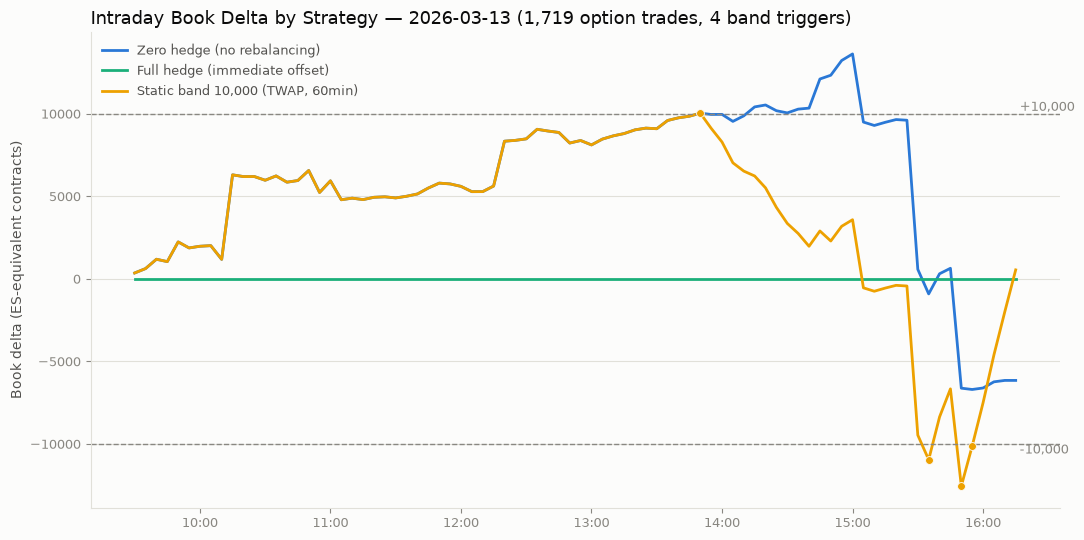

Wrote figure to outputs\figures\intraday_delta_path_by_strategy.png


In [12]:
import matplotlib.dates as mdates
import matplotlib.pyplot as plt

# Chart palette (validated categorical slots 1/2/3 in fixed order).
SURFACE = '#fcfcfb'
INK_PRIMARY = '#0b0b0b'
INK_SECONDARY = '#52514e'
INK_MUTED = '#898781'
GRID_COLOR = '#e1e0d9'
COLOR_ZERO_HEDGE = '#2a78d6'
COLOR_FULL_HEDGE = '#1baf7a'
COLOR_STATIC_BAND = '#eda100'

ILLUSTRATIVE_BAND = 10_000
ILLUSTRATIVE_METHOD = 'twap'
ILLUSTRATIVE_HORIZON = 60
MIN_TRIGGERS_FOR_SAMPLE_DAY = 2

# Pick the busiest trading day (by executed option trades) on which the
# illustrative band is breached multiple times, so the chart shows a real
# trigger -> unwind -> re-accumulation cycle rather than a flat line.
candidate_days = []
for trade_date, day_grid in bar_grid.groupby('trade_date'):
    day_grid = day_grid.sort_values('bar_time').reset_index(drop=True)
    _, day_triggers = simulate_static_band_day_path(day_grid, ILLUSTRATIVE_BAND, ILLUSTRATIVE_METHOD, ILLUSTRATIVE_HORIZON)
    if len(day_triggers) >= MIN_TRIGGERS_FOR_SAMPLE_DAY:
        candidate_days.append((trade_date, day_grid['n_option_trades'].sum(), len(day_triggers)))

candidate_days_df = pd.DataFrame(candidate_days, columns=['trade_date', 'n_option_trades', 'n_triggers'])
sample_day = candidate_days_df.sort_values('n_option_trades', ascending=False)['trade_date'].iloc[0]

day_grid_sample = (
    bar_grid.loc[bar_grid['trade_date'].eq(sample_day)]
    .sort_values('bar_time')
    .reset_index(drop=True)
)

zero_hedge_delta = day_grid_sample['option_delta_arrival'].cumsum().to_numpy()
full_hedge_delta = np.zeros(len(day_grid_sample))

static_band_path, static_band_triggers = simulate_static_band_day_path(
    day_grid_sample, ILLUSTRATIVE_BAND, ILLUSTRATIVE_METHOD, ILLUSTRATIVE_HORIZON
)

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ax.plot(day_grid_sample['bar_time'], zero_hedge_delta, color=COLOR_ZERO_HEDGE, linewidth=2, label='Zero hedge (no rebalancing)')
ax.plot(day_grid_sample['bar_time'], full_hedge_delta, color=COLOR_FULL_HEDGE, linewidth=2, label='Full hedge (immediate offset)')
ax.plot(
    static_band_path['bar_time'], static_band_path['book_delta'], color=COLOR_STATIC_BAND, linewidth=2,
    label=f'Static band {ILLUSTRATIVE_BAND:,.0f} ({ILLUSTRATIVE_METHOD.upper()}, {ILLUSTRATIVE_HORIZON}min)',
)
if not static_band_triggers.empty:
    ax.scatter(
        static_band_triggers['bar_time'], static_band_triggers['book_delta'], color=COLOR_STATIC_BAND, s=32,
        zorder=5, edgecolor=SURFACE, linewidth=0.6,
    )

ax.axhline(ILLUSTRATIVE_BAND, color=INK_MUTED, linestyle='--', linewidth=1)
ax.axhline(-ILLUSTRATIVE_BAND, color=INK_MUTED, linestyle='--', linewidth=1)
ax.text(day_grid_sample['bar_time'].iloc[-1], ILLUSTRATIVE_BAND, f' +{ILLUSTRATIVE_BAND:,.0f}', color=INK_MUTED, fontsize=9, va='bottom')
ax.text(day_grid_sample['bar_time'].iloc[-1], -ILLUSTRATIVE_BAND, f' -{ILLUSTRATIVE_BAND:,.0f}', color=INK_MUTED, fontsize=9, va='top')

n_trades_sample = int(day_grid_sample['n_option_trades'].sum())
ax.set_title(
    f'Intraday Book Delta by Strategy — {sample_day.date()} ({n_trades_sample:,} option trades, {len(static_band_triggers)} band triggers)',
    color=INK_PRIMARY, fontsize=13, loc='left',
)
ax.set_ylabel('Book delta (ES-equivalent contracts)', color=INK_SECONDARY, fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color(GRID_COLOR)
ax.tick_params(colors=INK_MUTED, labelsize=9)

legend = ax.legend(loc='upper left', frameon=False, fontsize=9)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)

fig.tight_layout()

fig_path = OUTPUT_FIGURE_DIR / 'intraday_delta_path_by_strategy.png'
fig.savefig(fig_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f'Wrote figure to {fig_path.relative_to(PROJECT_ROOT)}')

## 13. Delta PnL: The Cost of Carrying Unhedged Exposure

Book delta by itself only shows exposure; it doesn't show what that exposure costs or earns as the underlying moves. This section converts each strategy's book-delta path from Section 12 into a cumulative delta PnL: the mark-to-market gain or loss from carrying the prior bar's book delta through the next price move, `pnl_bar = book_delta[t-1] * (es1_price[t] - es1_price[t-1])`, cumulated across the day. Full hedge stays flat at zero PnL by construction (it never carries delta between bars); zero hedge and the static band show how much directional P&L swings the book absorbs by not being immediately flat.

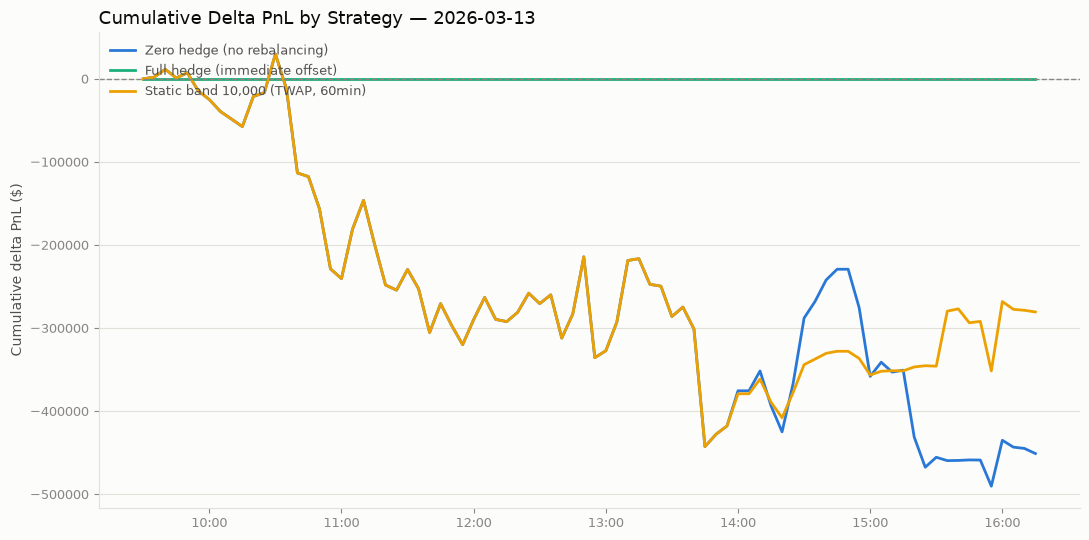

Wrote figure to outputs\figures\intraday_delta_pnl_by_strategy.png
End-of-day delta PnL — zero hedge: -450,942, full hedge: 0, static band: -280,534


In [13]:
def compute_delta_pnl(book_delta: np.ndarray, price: np.ndarray) -> np.ndarray:
    """Cumulative mark-to-market PnL from carrying book_delta[t-1] through the price move to t."""
    price_diff = np.diff(price, prepend=price[0])
    delta_prev = np.concatenate([[0.0], book_delta[:-1]])
    return np.cumsum(delta_prev * price_diff)


price_sample = day_grid_sample['es1_price'].to_numpy()

zero_hedge_pnl = compute_delta_pnl(zero_hedge_delta, price_sample)
full_hedge_pnl = compute_delta_pnl(full_hedge_delta, price_sample)
static_band_pnl = compute_delta_pnl(static_band_path['book_delta'].to_numpy(), price_sample)

fig, ax = plt.subplots(figsize=(11, 5.5))
fig.patch.set_facecolor(SURFACE)
ax.set_facecolor(SURFACE)

ax.plot(day_grid_sample['bar_time'], zero_hedge_pnl, color=COLOR_ZERO_HEDGE, linewidth=2, label='Zero hedge (no rebalancing)')
ax.plot(day_grid_sample['bar_time'], full_hedge_pnl, color=COLOR_FULL_HEDGE, linewidth=2, label='Full hedge (immediate offset)')
ax.plot(
    day_grid_sample['bar_time'], static_band_pnl, color=COLOR_STATIC_BAND, linewidth=2,
    label=f'Static band {ILLUSTRATIVE_BAND:,.0f} ({ILLUSTRATIVE_METHOD.upper()}, {ILLUSTRATIVE_HORIZON}min)',
)
ax.axhline(0, color=INK_MUTED, linestyle='--', linewidth=1)

ax.set_title(f'Cumulative Delta PnL by Strategy — {sample_day.date()}', color=INK_PRIMARY, fontsize=13, loc='left')
ax.set_ylabel('Cumulative delta PnL ($)', color=INK_SECONDARY, fontsize=10)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.grid(axis='y', color=GRID_COLOR, linewidth=0.8)
for side in ('top', 'right'):
    ax.spines[side].set_visible(False)
for side in ('left', 'bottom'):
    ax.spines[side].set_color(GRID_COLOR)
ax.tick_params(colors=INK_MUTED, labelsize=9)

legend = ax.legend(loc='upper left', frameon=False, fontsize=9)
for text in legend.get_texts():
    text.set_color(INK_SECONDARY)

fig.tight_layout()

pnl_fig_path = OUTPUT_FIGURE_DIR / 'intraday_delta_pnl_by_strategy.png'
fig.savefig(pnl_fig_path, dpi=150, facecolor=fig.get_facecolor())
plt.show()

print(f'Wrote figure to {pnl_fig_path.relative_to(PROJECT_ROOT)}')
print(f'End-of-day delta PnL — zero hedge: {zero_hedge_pnl[-1]:,.0f}, full hedge: {full_hedge_pnl[-1]:,.0f}, static band: {static_band_pnl[-1]:,.0f}')